<a href="https://colab.research.google.com/github/nataliagdorado/MachineLearningMenstrualIrregularities/blob/main/Notebook_3_Data_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving MentrualSetFinalCSV.csv to MentrualSetFinalCSV (4).csv


In [ ]:
import pandas as pd

filename = list(uploaded.keys())[0]
print("Archivo detectado:", filename)

df = pd.read_csv(filename, sep=';')  # <-- ¡IMPORTANTE!
print("Dataset cargado con shape:", df.shape)

display(df.head())
df.info()


Archivo detectado: MentrualSetFinalCSV (4).csv
Dataset cargado con shape: (10000, 17)


,avg_bleeding_days,Oligomenorrhea,Polymenorrhea,Menorrhagia,Amenorrhea,age,bmi,tracking_duration_months,pain_score,avg_cycle_length,cycle_length_variation,bleeding_volume_score,intermenstrual_episodes,cycle_variation_coeff,pattern_disruption_score,life_stage,duration_abnormality_flag
0,5,1.0,0.0,0.0,0.0,51,19.4,22,2,27.783958,59.154302,2,1,0.000000,20.000000,perimenopausal,0
1,4,1.0,0.0,0.0,0.0,41,22.4,15,0,27.783958,26.434149,2,0,48.610705,10.000000,reproductive,0
2,4,1.0,0.0,0.0,0.0,27,27.0,12,1,38.211179,39.886876,2,0,103.660141,92.928112,reproductive,0
3,4,0.0,1.0,0.0,0.0,20,22.4,14,1,27.783958,23.175502,2,0,121.021249,100.000000,reproductive,0
4,4,0.0,0.0,0.0,1.0,33,22.8,11,3,27.783958,0.000000,2,0,0.000000,10.000000,reproductive,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   avg_bleeding_days          10000 non-null  int64  
 1   Oligomenorrhea             10000 non-null  float64
 2   Polymenorrhea              10000 non-null  float64
 3   Menorrhagia                10000 non-null  float64
 4   Amenorrhea                 10000 non-null  float64
 5   age                        10000 non-null  int64  
 6   bmi                        10000 non-null  float64
 7   tracking_duration_months   10000 non-null  int64  
 8   pain_score                 10000 non-null  int64  
 9   avg_cycle_length           10000 non-null  float64
 10  cycle_length_variation     10000 non-null  float64
 11  bleeding_volume_score      10000 non-null  int64  
 12  intermenstrual_episodes    10000 non-null  int64  
 13  cycle_variation_coeff      10000 non-null  floa

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



df=pd.read_csv("MentrualSetFinalCSV.csv",sep=";")
df.head



<bound method NDFrame.head of       avg_bleeding_days  Oligomenorrhea  Polymenorrhea  Menorrhagia  \
0                     5             1.0            0.0          0.0   
1                     4             1.0            0.0          0.0   
2                     4             1.0            0.0          0.0   
3                     4             0.0            1.0          0.0   
4                     4             0.0            0.0          0.0   
...                 ...             ...            ...          ...   
9995                  3             1.0            0.0          0.0   
9996                  5             0.0            0.0          0.0   
9997                  1             0.0            0.0          0.0   
9998                  6             0.0            0.0          0.0   
9999                  4             0.0            0.0          0.0   

      Amenorrhea  age        bmi  tracking_duration_months  pain_score  \
0            0.0   51  19.400000                        22           2   
1            0.0   41  22.400000                        15           0   
2            0.0   27  27.000000                        12           1   
3            0.0   20  22.400000                        14           1   
4            1.0   33  22.800000                        11           3   
...          ...  ...        ...                       ...         ...   
9995         0.0   21  21.993951                         8           2   
9996         0.0   53  13.900000                        12           0   
9997         1.0   30  28.500000                        14           0   
9998         0.0   41  25.400000                        10           0   
9999         0.0   51  16.300000                         1           0   

      avg_cycle_length  cycle_length_variation  bleeding_volume_score  \
0            27.783958               59.154302                      2   
1            27.783958               26.434149                      2   
2            38.211179               39.886876                      2   
3            27.783958               23.175502                      2   
4            27.783958                0.000000                      2   
...                ...                     ...                    ...   
9995         49.644642               35.381858                      2   
9996         26.366028                1.444877                      2   
9997         27.783958                0.000000                      2   
9998         25.360131                0.685009                      2   
9999         28.312498               31.528745                      2   

      intermenstrual_episodes  cycle_variation_coeff  \
0                           1               0.000000   
1                           0              48.610705   
2                           0             103.660141   
3                           0             121.021249   
4                           0               0.000000   
...                       ...                    ...   
9995                        0              72.976463   
9996                        1              48.610705   
9997                        0               0.000000   
9998                        0               2.690870   
9999                        3             112.602660   

      pattern_disruption_score      life_stage  duration_abnormality_flag  
0                    20.000000  perimenopausal                          0  
1                    10.000000    reproductive                          0  
2                    92.928112    reproductive                          0  
3                   100.000000    reproductive                          0  
4                    10.000000    reproductive                          1  
...                        ...             ...                        ...  
9995                 68.381171    reproductive                          0  
9996                 24.530104    reproductive                        

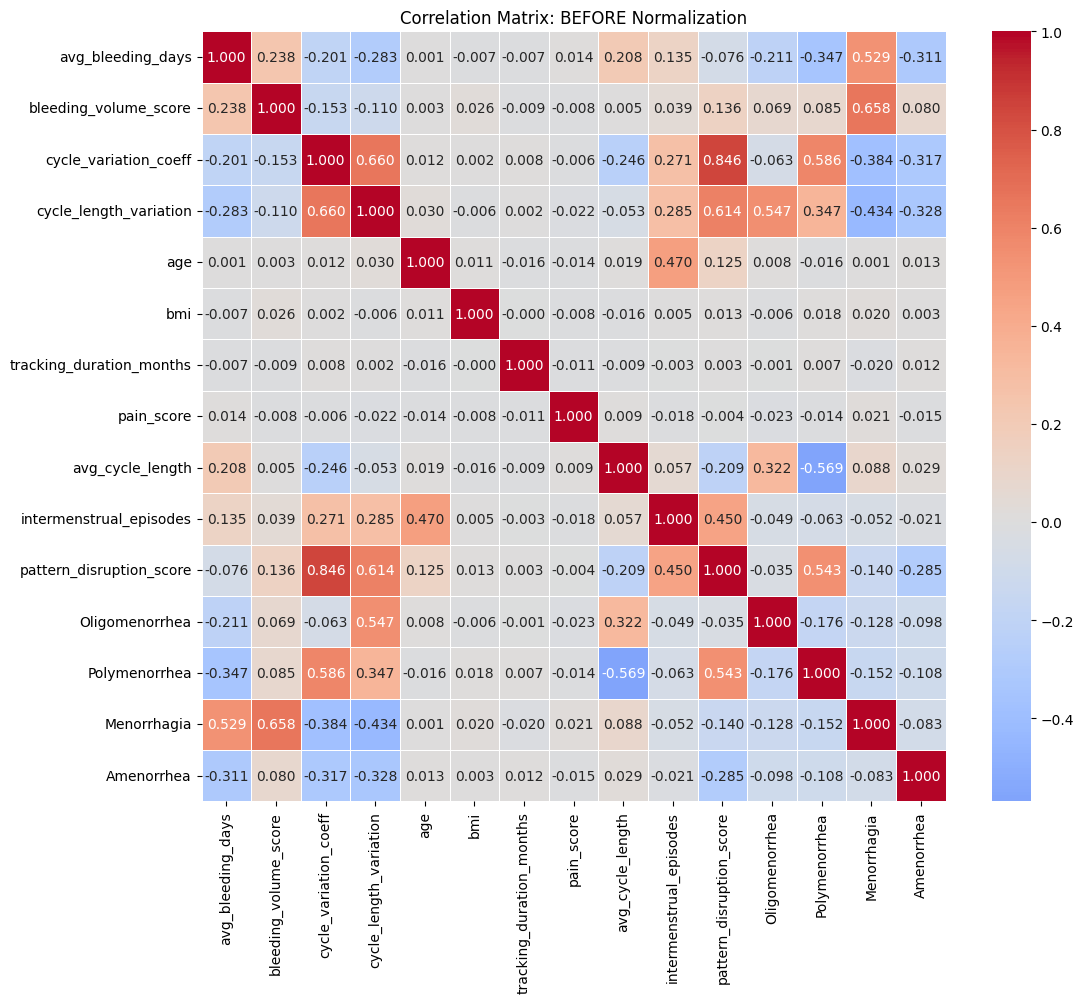

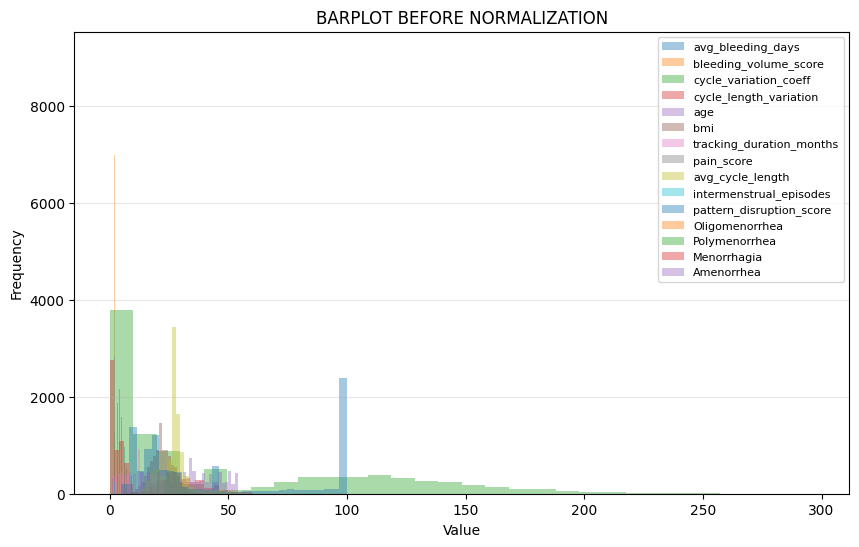

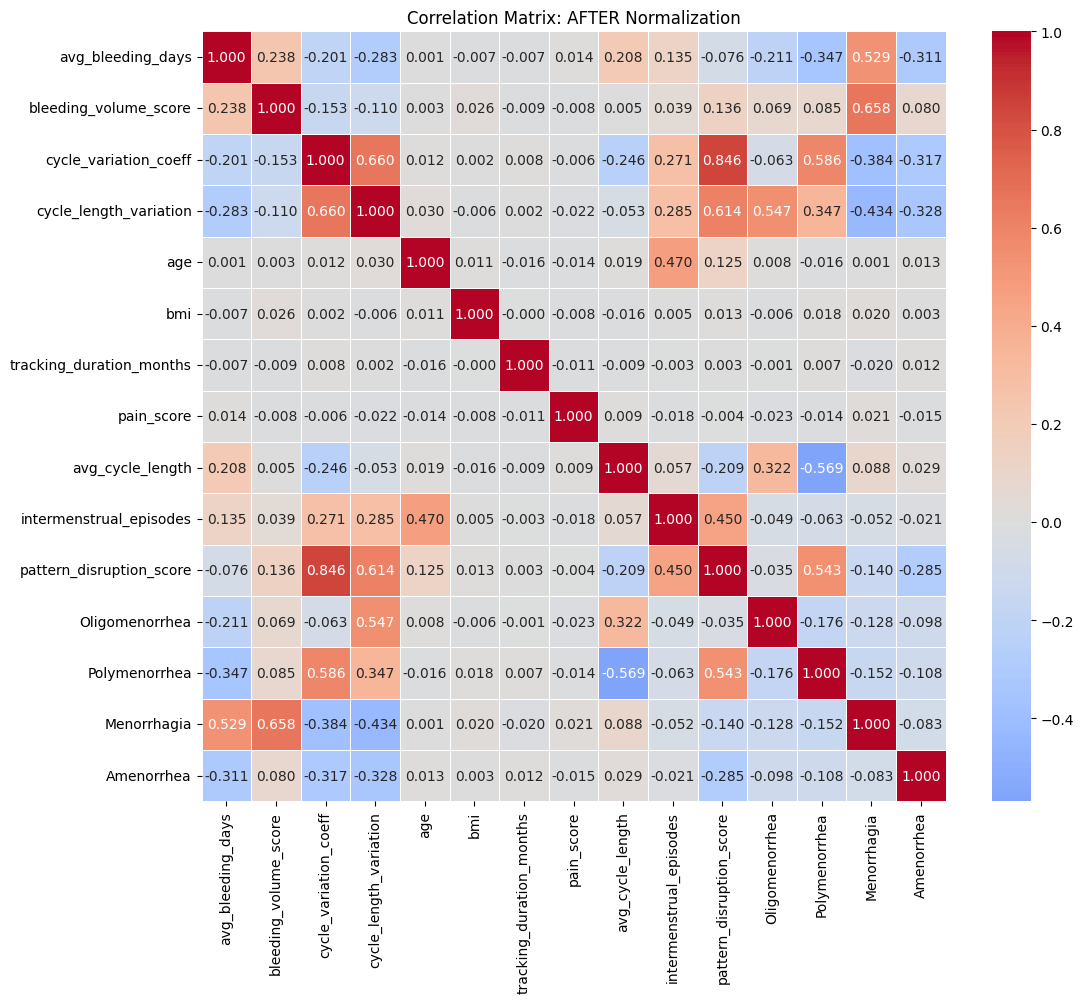

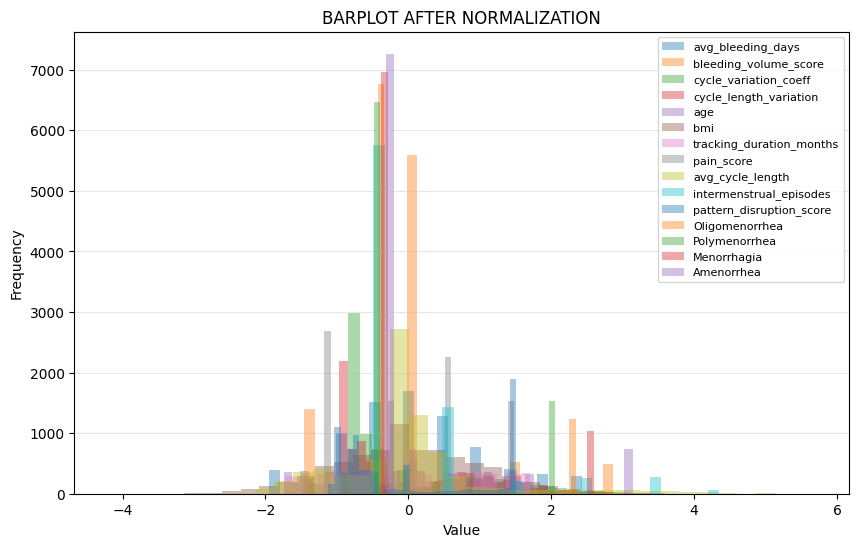

In [ ]:

myFeatures = [
    'avg_bleeding_days',
    'bleeding_volume_score',
    'cycle_variation_coeff',
    'cycle_length_variation',
    'age',
    'bmi',
    'tracking_duration_months',
    'pain_score',
    'avg_cycle_length',
    'intermenstrual_episodes',
    'pattern_disruption_score',
    'Oligomenorrhea',
    'Polymenorrhea',
    'Menorrhagia',
    'Amenorrhea'
]

X = df[myFeatures]
y=df['duration_abnormality_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#CORR MATRIX BEFORE NORMALIZATION:

plt.figure(figsize=(12, 10))
corr_antes = X_train.corr(method="spearman")
sns.heatmap(corr_antes, cmap="coolwarm", center=0, annot=True, fmt=".3f", linewidths=0.5)
plt.title("Correlation Matrix: BEFORE Normalization")
plt.show()

#BARPLOT BEFORE NORMALIZATION:
plt.figure(figsize=(10,6))

for col in myFeatures:
  plt.hist(
      df[col],
      bins=30,
      alpha=0.4,
      density=False,
      label=col
  )
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("BARPLOT BEFORE NORMALIZATION")
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.show()

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=myFeatures, index=X_train.index)
X_test_scaled_df=pd.DataFrame(X_test_scaled, columns=myFeatures, index=X_test.index)

#CORR MATRIX AFTER NORMALIZATION

plt.figure(figsize=(12, 10))
corr_despues = X_train_scaled_df.corr(method="spearman")
sns.heatmap(corr_despues, cmap="coolwarm", center=0, annot=True, fmt=".3f", linewidths=0.5)
plt.title("Correlation Matrix: AFTER Normalization")
plt.show()

#BARPLOT AFTER NORMALIZATION
plt.figure(figsize=(10,6))

for col in X_train_scaled_df:
  plt.hist(
      X_train_scaled_df[col],
      bins=30,
      alpha=0.4,
      density=False,
      label=col
  )
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("BARPLOT AFTER NORMALIZATION")
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.show()



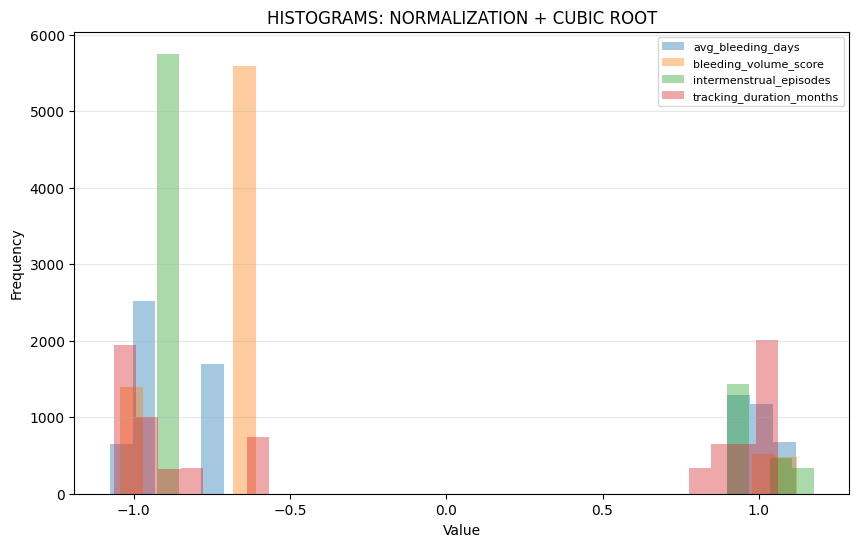

In [ ]:
skewFeatures=[
    'avg_bleeding_days',
    'bleeding_volume_score',
    'intermenstrual_episodes',
    'tracking_duration_months'
]

for col in skewFeatures:
  X_train_scaled_df[col]=np.cbrt(X_train_scaled_df[col])
  X_test_scaled_df[col]=np.cbrt(X_test_scaled_df[col])


plt.figure(figsize=(10,6))

for col in skewFeatures:
    plt.hist(
        X_train_scaled_df[col],
        bins=30,
        alpha=0.4,
        label=col
    )
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("HISTOGRAMS: NORMALIZATION + CUBIC ROOT")
plt.legend(fontsize=8)
plt.grid(axis="y", alpha=0.3)
plt.show()